In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import os

import pyrootutils

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")
os.environ.setdefault("TF_XLA_FLAGS", "--tf_xla_auto_jit=0")
os.environ.setdefault("TF_GPU_ALLOCATOR", "cuda_malloc_async")

ROOT = pyrootutils.setup_root(
    search_from=Path.cwd(),
    indicator="pyproject.toml",
    pythonpath=True,
    dotenv=True,
)



In [3]:
from building.scaling_experiment import (
    ScalingRunConfig,
    load_full_arrays,
    run_experiments,
    summarize_results,
    plot_summary,
)

2026-04-09 14:38:49.097142: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-09 14:38:49.114297: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-09 14:38:49.114327: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
COLLECTION = "diff_species"
N_SAMPLES = 20
EPOCHS = 30
PATIENCE = 3
BATCH_SIZE = 32
SEED = 42
THRESHOLD = 0.5
BUILD_MODEL = "cnn2d"
INPUT_REPR = "mel"
MODELS_DIR = ROOT / "models" / "scaling_mel"
RESULTS_FILE = MODELS_DIR / "results.jsonl"

In [5]:
config = ScalingRunConfig(
    collection=COLLECTION,
    build_model=BUILD_MODEL,
    epochs=EPOCHS,
    patience=PATIENCE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    threshold=THRESHOLD,
    models_dir=MODELS_DIR,
    results_file=RESULTS_FILE,
    input_repr=INPUT_REPR,
)

arrays = load_full_arrays(
    collection=COLLECTION,
    batch_size=BATCH_SIZE,
    seed=SEED,
    input_repr=INPUT_REPR,
)

print(f"Loaded {len(arrays.class_names)} classes:")
print(arrays.class_names)

Found 17499 files belonging to 10 classes.
Found 3749 files belonging to 10 classes.
Found 3751 files belonging to 10 classes.
Loaded 10 classes:
['Phylloscopus_bonelli', 'Phylloscopus_collybita', 'Phylloscopus_fuscatus', 'Phylloscopus_humei', 'Phylloscopus_ibericus', 'Phylloscopus_inornatus', 'Phylloscopus_sibilatrix', 'Phylloscopus_trochiloides', 'Phylloscopus_trochilus', 'Phylloscopus_xanthoschistos']


In [6]:
baseline_rows = run_experiments(arrays, config, run_baseline=True, run_scaling=False)
print(f"New baseline runs: {len(baseline_rows)}")
if baseline_rows:
    print("Last baseline row:")
    print(baseline_rows[-1])

[baseline] target=Phylloscopus_bonelli
[baseline] n_each=1750 n_non_target=1750 n_classes=2
Epoch 1/30


I0000 00:00:1775738362.303583   10580 service.cc:145] XLA service 0x7c1c0800c5e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775738362.303611   10580 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
I0000 00:00:1775738364.744361   10580 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


110/110 - 6s - 57ms/step - accuracy: 0.5523 - loss: 0.6767 - precision: 0.5431 - recall: 0.6154 - val_accuracy: 0.5893 - val_loss: 0.6694 - val_precision: 0.5885 - val_recall: 0.5893
Epoch 2/30
110/110 - 1s - 5ms/step - accuracy: 0.6466 - loss: 0.6186 - precision: 0.6463 - recall: 0.6469 - val_accuracy: 0.7627 - val_loss: 0.5463 - val_precision: 0.7627 - val_recall: 0.7627
Epoch 3/30
110/110 - 0s - 4ms/step - accuracy: 0.7357 - loss: 0.5524 - precision: 0.7357 - recall: 0.7366 - val_accuracy: 0.8333 - val_loss: 0.4909 - val_precision: 0.8333 - val_recall: 0.8333
Epoch 4/30
110/110 - 0s - 4ms/step - accuracy: 0.7760 - loss: 0.5079 - precision: 0.7761 - recall: 0.7766 - val_accuracy: 0.8667 - val_loss: 0.4525 - val_precision: 0.8667 - val_recall: 0.8667
Epoch 5/30
110/110 - 0s - 4ms/step - accuracy: 0.8123 - loss: 0.4653 - precision: 0.8093 - recall: 0.8174 - val_accuracy: 0.8867 - val_loss: 0.4109 - val_precision: 0.8718 - val_recall: 0.8973
Epoch 6/30
110/110 - 0s - 4ms/step - accuracy

In [7]:
import pandas as pd

def print_per_class_baseline_results(arrays, results_file):
    try:
        df = pd.read_json(results_file, lines=True)
    except Exception as e:
        print(f"Could not read results file: {e}")
        return

    baseline_df = df[df["run_type"] == "baseline"].copy()
    class_names = list(arrays.class_names)

    # Calculate the longest class name
    max_cls_len = max((len(str(cls)) for cls in class_names), default=0)
    col_width = max(max_cls_len + 2, 15)

    header = f"{'Target Class':<{col_width}} | {'Precision':>9} | {'Recall':>9} | {'Epochs':>6} | {'Timestamp'}"
    print(header)
    print("-" * len(header))

    for cls in class_names:
        cls_str = f"'{cls}'"
        matches = baseline_df[baseline_df["target_class"] == cls]
        
        row = matches.iloc[-1]
        prec = row.get("precision")
        rec = row.get("recall")
        epochs = row.get("epochs_trained")
        timestamp = row.get("timestamp")
        # Print the aligned single row
        print(f"{cls_str:<{col_width}} | {prec:>9.4f} | {rec:>9.4f} | {epochs:>6.0f} | {timestamp!s}")

print_per_class_baseline_results(arrays, RESULTS_FILE)

Target Class                  | Precision |    Recall | Epochs | Timestamp
--------------------------------------------------------------------------
'Phylloscopus_bonelli'        |    0.9272 |    0.9267 |     24 | 2026-04-09 12:39:38.801315+00:00
'Phylloscopus_collybita'      |    0.5000 |    0.5000 |      5 | 2026-04-09 12:39:45.452724+00:00
'Phylloscopus_fuscatus'       |    0.9403 |    0.9388 |     19 | 2026-04-09 12:39:59.637226+00:00
'Phylloscopus_humei'          |    0.0000 |    0.0000 |      8 | 2026-04-09 12:40:07.689283+00:00
'Phylloscopus_ibericus'       |    0.8897 |    0.8867 |     26 | 2026-04-09 12:40:22.983862+00:00
'Phylloscopus_inornatus'      |    0.9236 |    0.9307 |     10 | 2026-04-09 12:40:31.698998+00:00
'Phylloscopus_sibilatrix'     |    0.9387 |    0.9373 |     23 | 2026-04-09 12:40:46.633595+00:00
'Phylloscopus_trochiloides'   |    0.5000 |    1.0000 |     11 | 2026-04-09 12:40:56.351207+00:00
'Phylloscopus_trochilus'      |    0.5000 |    0.5000 |     10 | 2

In [ ]:
scaling_rows = run_experiments(
    arrays=arrays,
    config=config,
    n_samples=N_SAMPLES,
    k_values=range(2, len(arrays.class_names)),
    run_baseline=False,
    run_scaling=True,
)
print(f"New scaling runs: {len(scaling_rows)}")
if scaling_rows:
    print("Last scaling row:")
    print(scaling_rows[-1])

[scaling] k=2 sample=1/20
[scaling] n_each=1750 n_non_target=1750 n_classes=3
Epoch 1/30
165/165 - 6s - 39ms/step - accuracy: 0.3722 - loss: 0.6517 - precision: 0.3350 - recall: 0.0131 - val_accuracy: 0.5662 - val_loss: 0.6363 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/30
165/165 - 1s - 4ms/step - accuracy: 0.5112 - loss: 0.6066 - precision: 0.6094 - recall: 0.0891 - val_accuracy: 0.4791 - val_loss: 0.5865 - val_precision: 0.6451 - val_recall: 0.4071
Epoch 3/30
165/165 - 1s - 5ms/step - accuracy: 0.5509 - loss: 0.5703 - precision: 0.5913 - recall: 0.5053 - val_accuracy: 0.6356 - val_loss: 0.5370 - val_precision: 0.7059 - val_recall: 0.5484
Epoch 4/30
165/165 - 1s - 4ms/step - accuracy: 0.5699 - loss: 0.5491 - precision: 0.6010 - recall: 0.5269 - val_accuracy: 0.6524 - val_loss: 0.5129 - val_precision: 0.7219 - val_recall: 0.5653
Epoch 5/30
165/165 - 1s - 4ms/step - accuracy: 0.5749 - loss: 0.5359 - precision: 0.6066 - recall: 0.5320 - val_accuracy: 0.6560 - val_loss: 

In [ ]:
baseline_metrics, summary_df = summarize_results(RESULTS_FILE)
print(f"Baseline recall: {baseline_metrics.recall:.4f}")
print(f"Baseline precision: {baseline_metrics.precision:.4f}")
summary_df

Baseline recall: 0.8771
Baseline precision: 0.8298


,k,recall_mean,recall_std,precision_mean,precision_std,top1_acc_mean,top1_acc_std
0,2,0.520570,0.396804,0.632356,0.425724,0.680424,0.252298
1,3,0.547139,0.299947,0.776422,0.286510,0.716477,0.200372
2,4,0.422660,0.263098,0.725727,0.333190,0.638087,0.216848
3,5,0.321018,0.224154,0.752929,0.327561,0.570461,0.224235
4,6,0.267567,0.187657,0.718108,0.259034,0.550370,0.196691
5,7,0.230800,0.126870,0.786675,0.079620,0.563694,0.109511


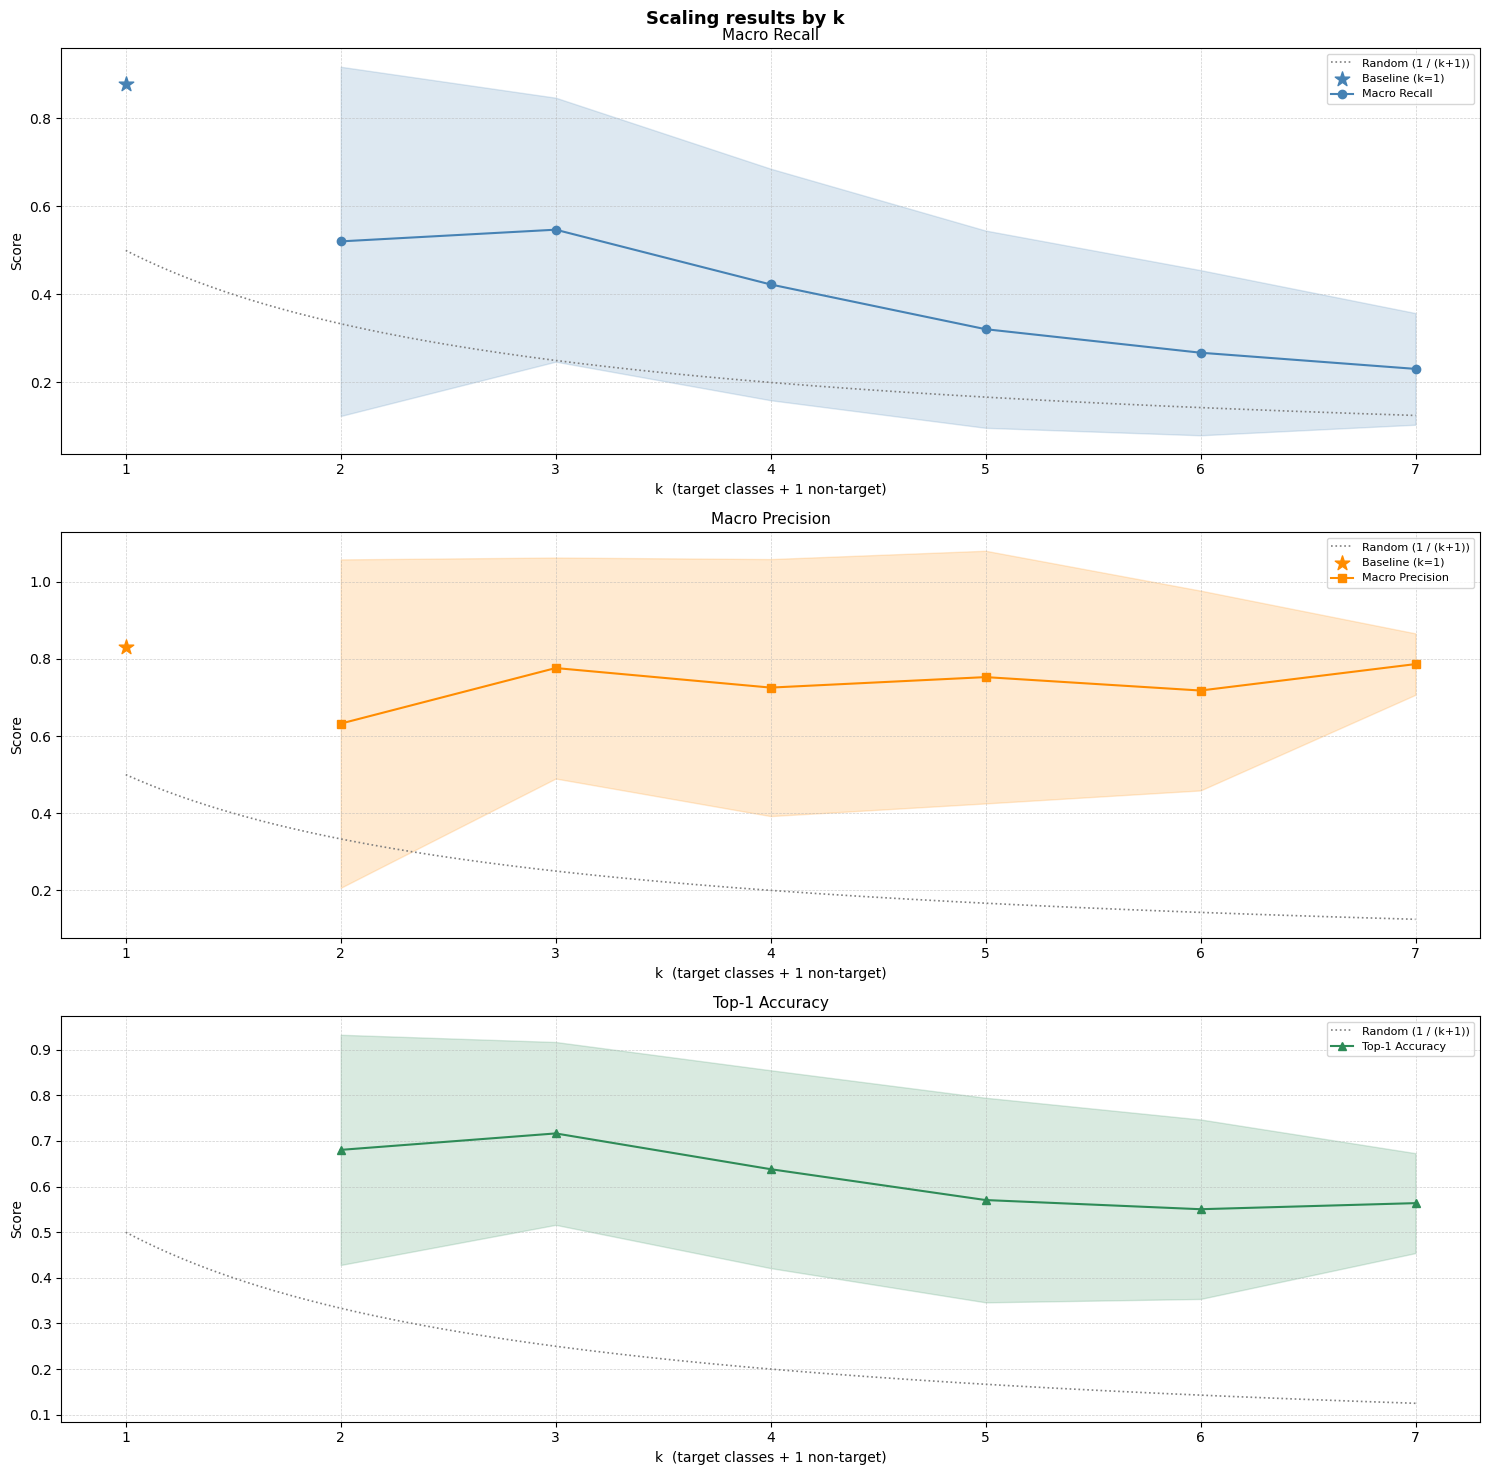

In [ ]:
plot_summary(summary_df, baseline=baseline_metrics)